In [8]:
import pandas as pd

In [39]:
import matplotlib.pyplot as plt

In [67]:
import numpy as np
from IPython.display import display

In [11]:
import os
import pandas as pd
from PIL import Image
import colorsys

def create_pixel_dataframe(image_folder):
    pixel_data = []
    
    for filename in os.listdir(image_folder):
        if filename.lower().endswith(".png"):
            filepath = os.path.join(image_folder, filename)
            
            try:
                with Image.open(filepath) as img:
                    img = img.convert('RGB')
                    width, height = img.size
                    pixels = img.load()
                    
                    for x in range(width):
                        for y in range(height):
                            r, g, b = pixels[x, y]
                            h, l, s = colorsys.rgb_to_hls(r / 255.0, g / 255.0, b / 255.0)
                            
                            h_deg = round(h * 360, 2)
                            s_pct = round(s * 100, 2)
                            l_pct = round(l * 100, 2)
                            
                            pixel_data.append({
                                'file': filename,
                                'x': x,
                                'y': y,
                                'R': r,
                                'G': g,
                                'B': b,
                                'H': h_deg,
                                'S': s_pct,
                                'L': l_pct
                            })
            except Exception as e:
                print(f"Error processing the file {filename}: {e}")

    return pd.DataFrame(pixel_data)

images_pixels = create_pixel_dataframe("cat-flower")

images_pixels


,file,x,y,R,G,B,H,S,L
0,kwiatek-76.png,0,0,90,99,30,67.83,53.49,25.29
1,kwiatek-76.png,0,1,134,151,26,68.16,70.62,34.71
2,kwiatek-76.png,0,2,132,153,30,70.24,67.21,35.88
3,kwiatek-76.png,0,3,141,158,81,73.25,32.22,46.86
4,kwiatek-76.png,0,4,120,140,36,71.54,59.09,34.51
...,...,...,...,...,...,...,...,...,...
1319995,kwiatek-53.png,99,95,3,3,3,0.00,0.00,1.18
1319996,kwiatek-53.png,99,96,4,4,4,0.00,0.00,1.57
1319997,kwiatek-53.png,99,97,5,5,3,60.00,25.00,1.57
1319998,kwiatek-53.png,99,98,7,10,5,96.00,33.33,2.94


In [70]:
cats_pixels = images_pixels[images_pixels['file'].str.startswith('kotek')]
unique_colors_cats = cats_pixels.groupby(['R', 'G', 'B', 'H', 'S', 'L']).size().reset_index(name='count')
unique_colors_cats = unique_colors_cats.reset_index(drop=True)


flowers_pixels = images_pixels[images_pixels['file'].str.startswith('kwiatek')]
unique_colors_flowers = flowers_pixels.groupby(['R', 'G', 'B', 'H', 'S', 'L']).size().reset_index(name='count')
unique_colors_flowers = unique_colors_flowers.reset_index(drop=True)


max_RGB = unique_colors_cats[['R', 'G', 'B']].max(axis=1)
unique_colors_cats['is_dominating_R'] = (unique_colors_cats['R'] == max_RGB).astype(int)
unique_colors_cats['is_dominating_G'] = (unique_colors_cats['G'] == max_RGB).astype(int)
unique_colors_cats['is_dominating_B'] = (unique_colors_cats['B'] == max_RGB).astype(int)
unique_colors_cats['is_cold'] = ((unique_colors_cats['H'] >= 180) & (unique_colors_cats['H'] <= 270)).astype(int)
unique_colors_cats['is_saturated'] = (unique_colors_cats['S'] > 70).astype(int)

max_RGB = unique_colors_flowers[['R', 'G', 'B']].max(axis=1)
unique_colors_flowers['is_dominating_R'] = (unique_colors_flowers['R'] == max_RGB).astype(int)
unique_colors_flowers['is_dominating_G'] = (unique_colors_flowers['G'] == max_RGB).astype(int)
unique_colors_flowers['is_dominating_B'] = (unique_colors_flowers['B'] == max_RGB).astype(int)
unique_colors_flowers['is_cold'] = ((unique_colors_flowers['H'] >= 180) & (unique_colors_flowers['H'] <= 270)).astype(int)
unique_colors_flowers['is_saturated'] = (unique_colors_flowers['S'] > 70).astype(int)

In [66]:
unique_colors_cats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 419043 entries, 0 to 419042
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   R                419043 non-null  int64  
 1   G                419043 non-null  int64  
 2   B                419043 non-null  int64  
 3   H                419043 non-null  float64
 4   S                419043 non-null  float64
 5   L                419043 non-null  float64
 6   liczba_w_kotach  419043 non-null  int64  
 7   is_dominating_R  419043 non-null  int64  
 8   is_dominating_G  419043 non-null  int64  
 9   is_dominating_B  419043 non-null  int64  
 10  is_cold          419043 non-null  int64  
 11  is_saturated     419043 non-null  int64  
dtypes: float64(3), int64(9)
memory usage: 38.4 MB


In [ ]:
unique_colors_flowers

(np.float64(-0.5), np.float64(99.5), np.float64(99.5), np.float64(-0.5))

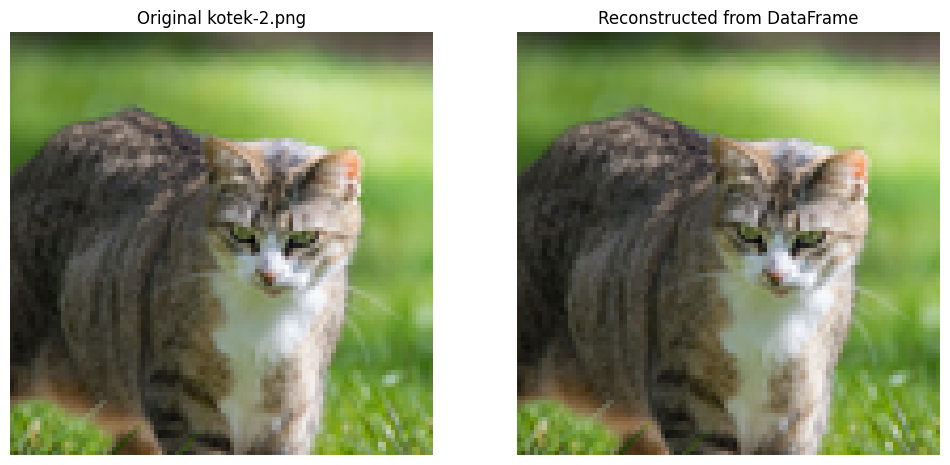

In [57]:
test_image_pixels = images_pixels[images_pixels['file'] == 'kotek-2.png']
width = height = 100
test_image = np.zeros((height, width, 3), dtype=np.uint8)
test_image[test_image_pixels['y'], test_image_pixels['x'], 0] = test_image_pixels['R']
test_image[test_image_pixels['y'], test_image_pixels['x'], 1] = test_image_pixels['G']
test_image[test_image_pixels['y'], test_image_pixels['x'], 2] = test_image_pixels['B']

test_image_photo = Image.open('cat-flower/kotek-2.png').convert('RGB')


fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(test_image_photo)
axes[0].set_title(f"Original kotek-2.png")
axes[0].axis('off')

axes[1].imshow(test_image)
axes[1].set_title(f"Reconstructed from DataFrame")
axes[1].axis('off')

Everything is working fine for now
Dataframes from task description are:
a) images_pixels
display(images_pixels.head(10))
b) unique_colors_cats, unique_colors_flowers

In [71]:
display(test_image_pixels.head())
display(unique_colors_cats.head())
display(unique_colors_flowers.head())

,file,x,y,R,G,B,H,S,L
370000,kotek-2.png,0,0,62,69,45,77.50,21.05,22.35
370001,kotek-2.png,0,1,67,80,49,85.16,24.03,25.29
370002,kotek-2.png,0,2,74,90,52,85.26,26.76,27.84
370003,kotek-2.png,0,3,79,98,57,87.80,26.45,30.39
370004,kotek-2.png,0,4,85,108,61,89.36,27.81,33.14


,R,G,B,H,S,L,count,is_dominating_R,is_dominating_G,is_dominating_B,is_cold,is_saturated
0,0,0,0,0.0,0.0,0.00,240,1,1,1,0,0
1,0,0,1,240.0,100.0,0.20,13,0,0,1,1,1
2,0,0,2,240.0,100.0,0.39,6,0,0,1,1,1
3,0,0,3,240.0,100.0,0.59,2,0,0,1,1,1
4,0,0,4,240.0,100.0,0.78,2,0,0,1,1,1


,R,G,B,H,S,L,count,is_dominating_R,is_dominating_G,is_dominating_B,is_cold,is_saturated
0,0,0,0,0.0,0.0,0.00,4462,1,1,1,0,0
1,0,0,1,240.0,100.0,0.20,325,0,0,1,1,1
2,0,0,2,240.0,100.0,0.39,62,0,0,1,1,1
3,0,0,3,240.0,100.0,0.59,16,0,0,1,1,1
4,0,0,4,240.0,100.0,0.78,3,0,0,1,1,1


In [82]:


images_colors = images_pixels.groupby('file').apply(lambda df: df[['R', 'G', 'B']].drop_duplicates().shape[0]).reset_index(name='unique_colors')
display(images_colors)
display(images_colors.describe())

/var/folders/yc/xp4k0lts05bbb_j1cxlzrdz00000gn/T/ipykernel_80604/4113383729.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  images_colors = images_pixels.groupby('file').apply(lambda df: df[['R', 'G', 'B']].drop_duplicates().shape[0]).reset_index(name='unique_colors')


,file,unique_colors
0,kotek-0.png,9177
1,kotek-1.png,9151
2,kotek-10.png,7918
3,kotek-11.png,8913
4,kotek-12.png,9648
...,...,...
127,kwiatek-74.png,5707
128,kwiatek-75.png,9795
129,kwiatek-76.png,9481
130,kwiatek-8.png,7893


,unique_colors
count,132.000000
mean,8649.393939
std,1163.402865
min,4538.000000
25%,7988.000000
50%,9072.500000
75%,9521.250000
max,9911.000000


In [83]:
cat_images_color_count = images_colors[images_colors['file'].str.startswith('kotek')]
flowers_images_color_count = images_colors[images_colors['file'].str.startswith('kwiatek')]

In [87]:
print("Flowers:")
display(flowers_images_color_count.describe())
print("Cats:")
display(cat_images_color_count.describe())

Flowers:


,unique_colors
count,77.000000
mean,8251.090909
std,1308.527217
min,4538.000000
25%,7348.000000
50%,8768.000000
75%,9315.000000
max,9881.000000


Cats:


,unique_colors
count,55.000000
mean,9207.018182
std,575.119295
min,7339.000000
25%,8943.000000
50%,9387.000000
75%,9609.000000
max,9911.000000


now i need to comment min, max mean and std of unique colors